# PREDIKSI HARGA RUMAH

Project ini menggunakan **Linear Regression** untuk memprediksi harga rumah berdasarkan fitur-fitur seperti:
- Luas bangunan (m²)
- Jumlah kamar tidur
- Jarak ke pusat kota (km)
- Usia bangunan (tahun)

**Library yang digunakan:**
- `pandas` — manipulasi data
- `numpy` — komputasi numerik
- `matplotlib` & `seaborn` — visualisasi
- `scikit-learn` — machine learning

## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style='whitegrid')
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## 2. Generate Dataset

Kita buat dataset simulasi 500 rumah dengan data yang realistis.

In [ ]:
np.random.seed(42)
n = 500

luas       = np.random.randint(36, 300, n)          # m²
kamar      = np.random.randint(1, 6, n)              # jumlah kamar
jarak_kota = np.round(np.random.uniform(1, 30, n), 1)  # km
usia       = np.random.randint(1, 40, n)             # tahun

# Rumus harga: kombinasi fitur + noise
harga = (
    luas       * 4_500_000 +
    kamar      * 15_000_000 -
    jarak_kota * 5_000_000 -
    usia       * 2_000_000 +
    np.random.normal(0, 30_000_000, n)
)
harga = np.clip(harga, 50_000_000, None)  # minimal 50 juta

df = pd.DataFrame({
    'luas_m2'    : luas,
    'kamar_tidur': kamar,
    'jarak_kota' : jarak_kota,
    'usia_tahun' : usia,
    'harga'      : harga.astype(int)
})

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (500, 5)


,luas_m2,kamar_tidur,jarak_kota,usia_tahun,harga
0,138,1,17.1,12,520565859
1,142,5,21.9,36,521107279
2,107,3,24.4,23,355870852
3,224,1,29.7,31,817081536
4,56,3,18.5,11,200145998
5,138,4,24.4,10,554260047
6,157,2,28.9,3,513048592
7,250,4,28.4,14,1012080754
8,123,4,5.1,16,510717342
9,135,5,12.8,10,590228182


## 3. Eksplorasi Data (EDA)

In [ ]:
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,luas_m2,kamar_tidur,jarak_kota,usia_tahun,harga
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,173.096000,2.948000,15.913400,19.720000,7.044034e+08
std,74.216838,1.437159,8.487263,11.401121,3.401228e+08
min,36.000000,1.000000,1.000000,1.000000,5.000000e+07
25%,110.000000,2.000000,8.675000,10.000000,4.212688e+08
50%,179.000000,3.000000,16.350000,20.000000,7.194817e+08
75%,233.000000,4.000000,23.075000,30.000000,9.742674e+08
max,299.000000,5.000000,30.000000,39.000000,1.395212e+09


In [ ]:
print('=== Cek Missing Values ===')
print(df.isnull().sum())
print('\nTidak ada missing value' if df.isnull().sum().sum() == 0 else 'Ada missing value!')

=== Cek Missing Values ===
luas_m2        0
kamar_tidur    0
jarak_kota     0
usia_tahun     0
harga          0
dtype: int64

Tidak ada missing value


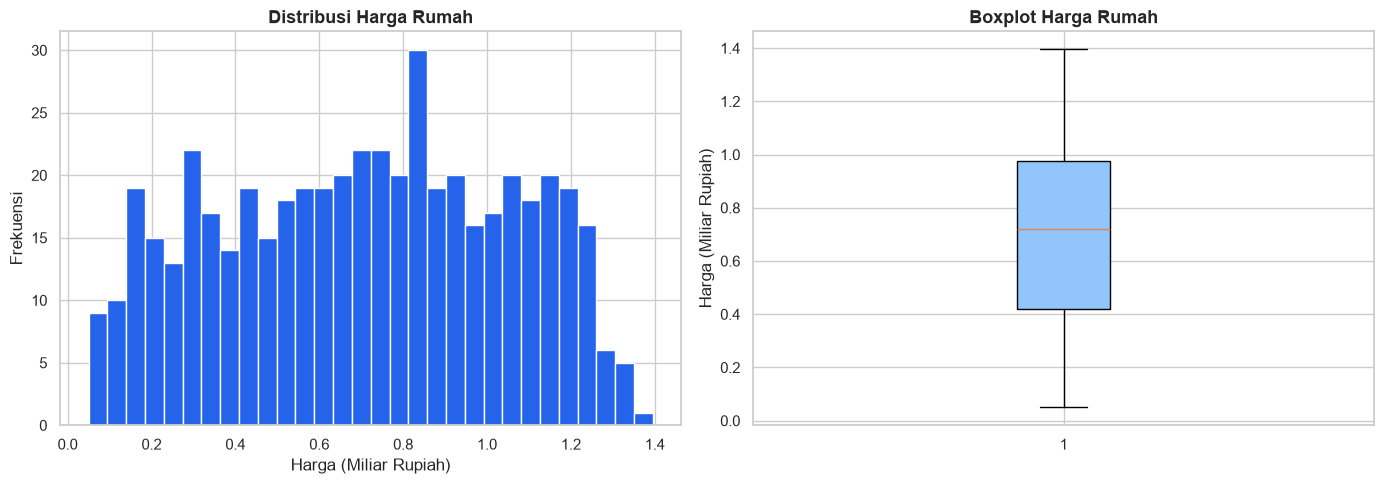

In [ ]:
# Distribusi harga rumah
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['harga'] / 1e9, bins=30, color='#2563eb', edgecolor='white')
axes[0].set_title('Distribusi Harga Rumah', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga (Miliar Rupiah)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['harga'] / 1e9, patch_artist=True,
                boxprops=dict(facecolor='#93c5fd'))
axes[1].set_title('Boxplot Harga Rumah', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Harga (Miliar Rupiah)')

plt.tight_layout()
plt.show()

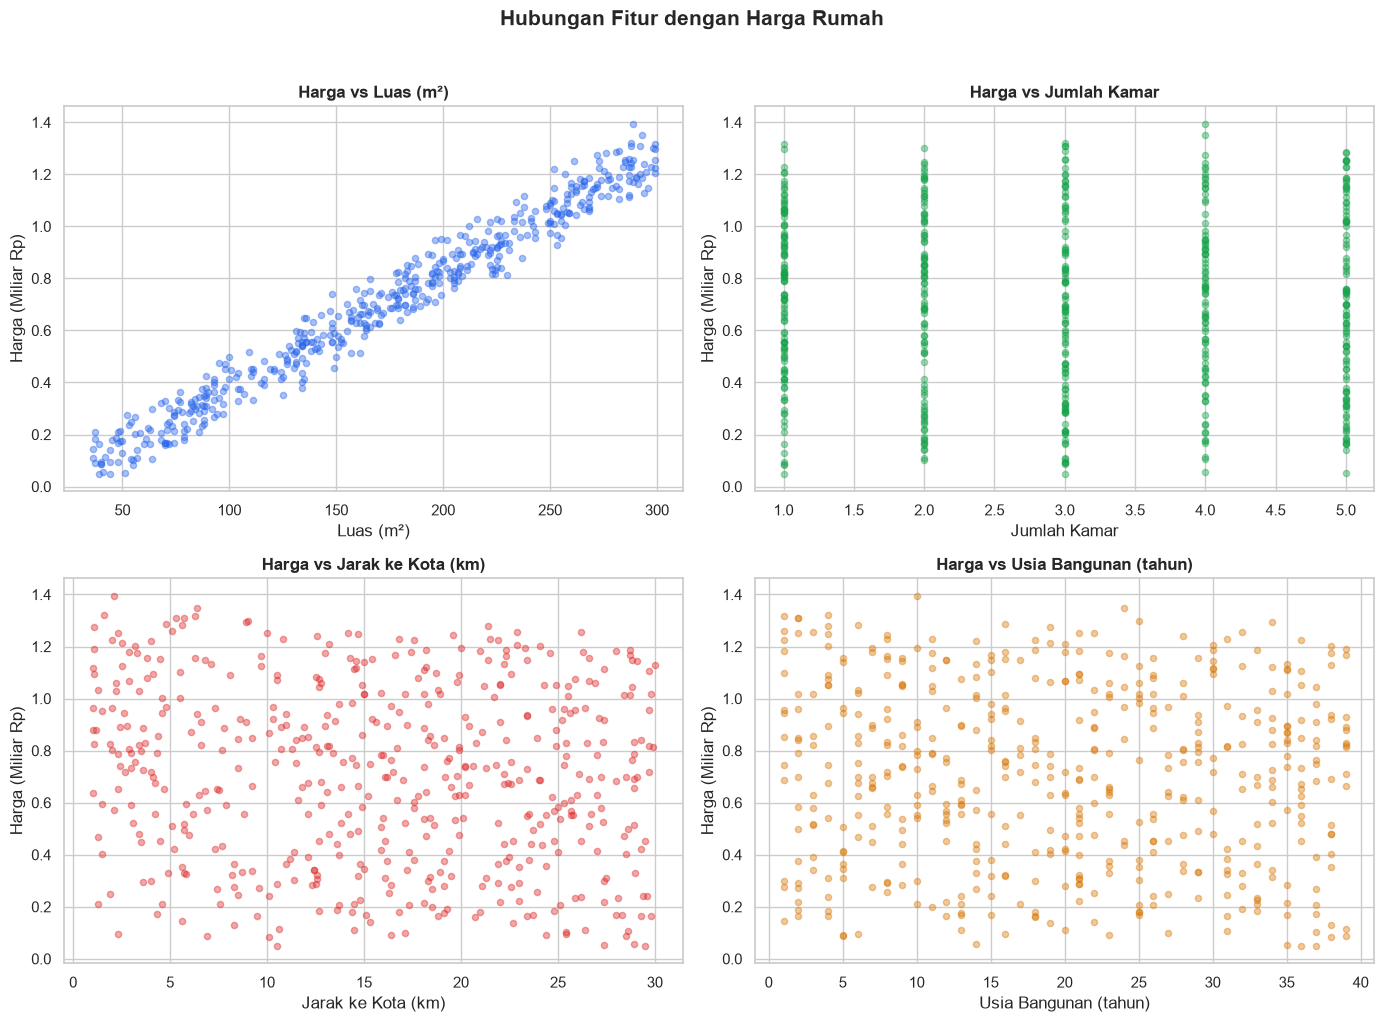

In [ ]:
# Scatter plot: hubungan tiap fitur dengan harga
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fitur = ['luas_m2', 'kamar_tidur', 'jarak_kota', 'usia_tahun']
label = ['Luas (m²)', 'Jumlah Kamar', 'Jarak ke Kota (km)', 'Usia Bangunan (tahun)']
warna = ['#2563eb', '#16a34a', '#dc2626', '#d97706']

for ax, f, l, w in zip(axes.flatten(), fitur, label, warna):
    ax.scatter(df[f], df['harga'] / 1e9, alpha=0.4, color=w, s=20)
    ax.set_xlabel(l)
    ax.set_ylabel('Harga (Miliar Rp)')
    ax.set_title(f'Harga vs {l}', fontweight='bold')

plt.suptitle('Hubungan Fitur dengan Harga Rumah', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

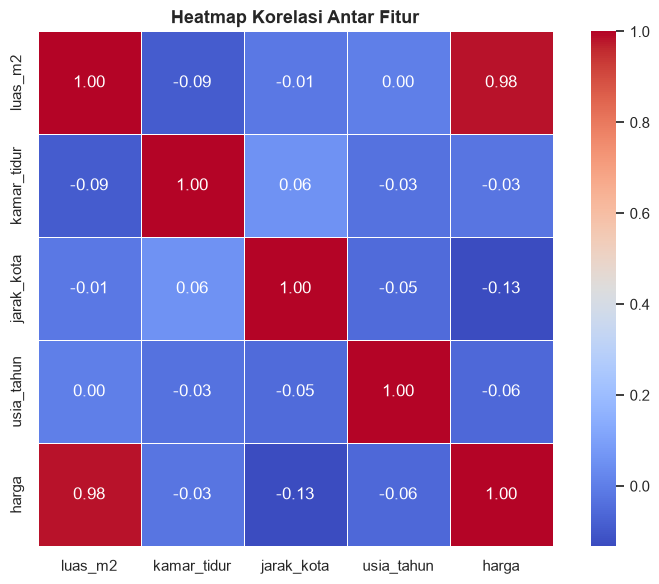

In [ ]:
# Heatmap korelasi
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing Data

In [ ]:
X = df[['luas_m2', 'kamar_tidur', 'jarak_kota', 'usia_tahun']]
y = df['harga']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Data Training : {X_train.shape[0]} sampel')
print(f'Data Testing  : {X_test.shape[0]} sampel')

Data Training : 400 sampel
Data Testing  : 100 sampel


## 5. Training Model

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model berhasil dilatih!')
print('\nKoefisien model:')
for fitur, koef in zip(X.columns, model.coef_):
    print(f'  {fitur:15s}: {koef:+,.0f}')
print(f'  {"intercept":15s}: {model.intercept_:+,.0f}')

✅ Model berhasil dilatih!

Koefisien model:
  luas_m2        : +332,524,177
  kamar_tidur    : +22,541,314
  jarak_kota     : -42,594,505
  usia_tahun     : -21,440,945
  intercept      : +694,722,078


## 6. Evaluasi Model

In [ ]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Hasil Evaluasi Model ===')
print(f'MAE  (Mean Absolute Error) : Rp {mae:,.0f}')
print(f'RMSE (Root Mean Sq. Error) : Rp {rmse:,.0f}')
print(f'R²   (Akurasi)             : {r2:.4f} ({r2*100:.2f}%)')

=== Hasil Evaluasi Model ===
MAE  (Mean Absolute Error) : Rp 22,485,337
RMSE (Root Mean Sq. Error) : Rp 28,558,733
R²   (Akurasi)             : 0.9935 (99.35%)


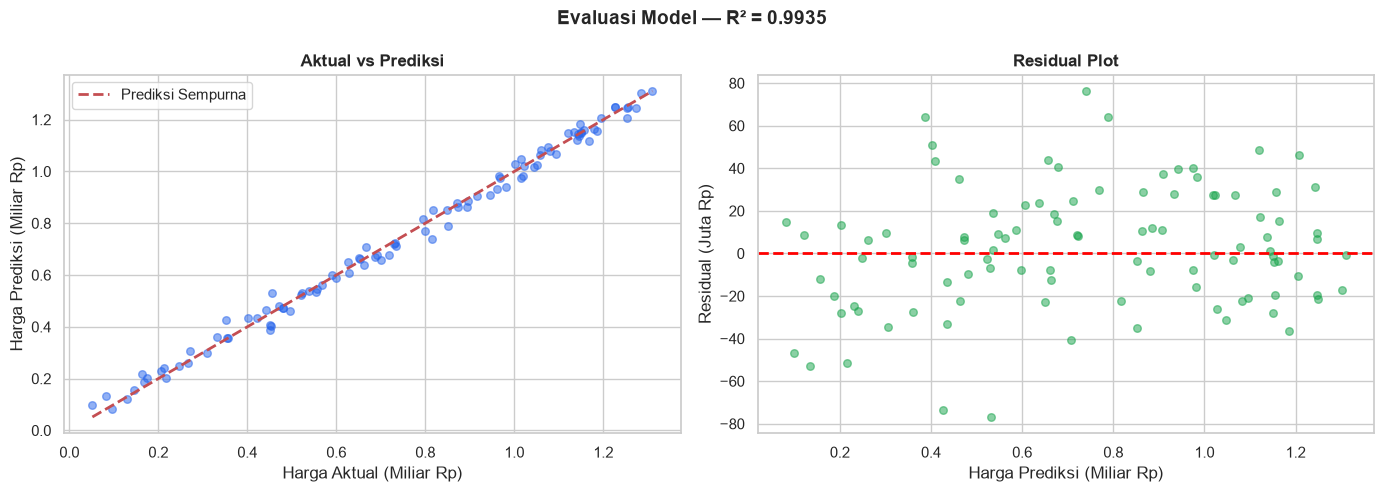

In [ ]:
# Visualisasi: Harga Aktual vs Prediksi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter actual vs predicted
axes[0].scatter(y_test / 1e9, y_pred / 1e9, alpha=0.5, color='#2563eb', s=30)
lims = [min(y_test.min(), y_pred.min()) / 1e9,
        max(y_test.max(), y_pred.max()) / 1e9]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Harga Aktual (Miliar Rp)')
axes[0].set_ylabel('Harga Prediksi (Miliar Rp)')
axes[0].set_title('Aktual vs Prediksi', fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred / 1e9, residuals / 1e6, alpha=0.5, color='#16a34a', s=30)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Harga Prediksi (Miliar Rp)')
axes[1].set_ylabel('Residual (Juta Rp)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.suptitle(f'Evaluasi Model — R² = {r2:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Prediksi Harga Rumah Baru

In [ ]:
# Contoh prediksi beberapa rumah baru
rumah_baru = pd.DataFrame({
    'luas_m2'    : [100, 150, 60,  200],
    'kamar_tidur': [3,   4,   2,   5  ],
    'jarak_kota' : [5,   10,  2,   20 ],
    'usia_tahun' : [5,   10,  1,   15 ]
})

rumah_baru_scaled = scaler.transform(rumah_baru)
prediksi = model.predict(rumah_baru_scaled)

rumah_baru['prediksi_harga'] = prediksi.astype(int)
rumah_baru['harga_format']   = rumah_baru['prediksi_harga'].apply(
    lambda x: f'Rp {x/1e9:.2f} M'
)

print('=== Prediksi Harga Rumah Baru ===')
rumah_baru

=== Prediksi Harga Rumah Baru ===


,luas_m2,kamar_tidur,jarak_kota,usia_tahun,prediksi_harga,harga_format
0,100,3,5,5,457099129,Rp 0.46 M
1,150,4,10,10,664259354,Rp 0.66 M
2,60,2,2,1,283183069,Rp 0.28 M
3,200,5,20,15,846285612,Rp 0.85 M


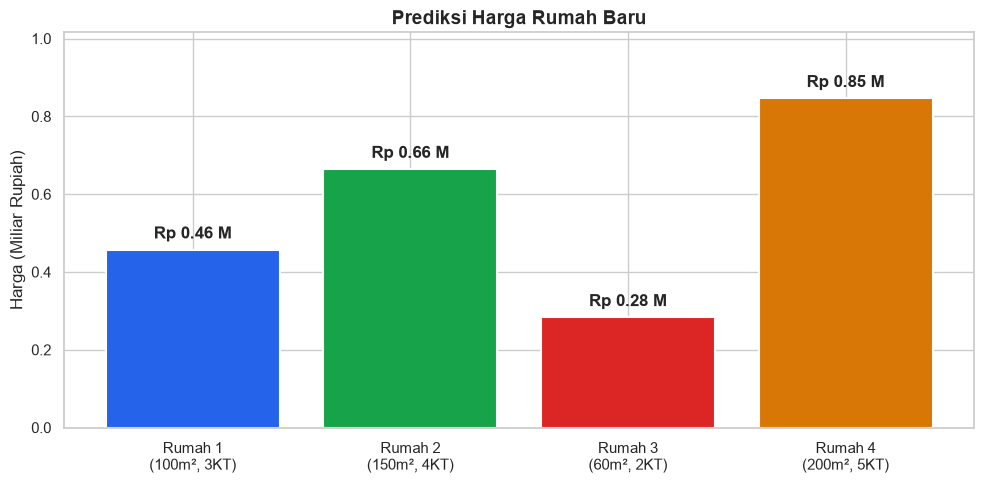

In [ ]:
# Visualisasi hasil prediksi rumah baru
labels = [f'Rumah {i+1}\n({r.luas_m2}m², {r.kamar_tidur}KT)'
          for i, r in rumah_baru.iterrows()]
harga_miliar = rumah_baru['prediksi_harga'] / 1e9
warna = ['#2563eb', '#16a34a', '#dc2626', '#d97706']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, harga_miliar, color=warna, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, harga_miliar):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'Rp {val:.2f} M',
             ha='center', va='bottom', fontweight='bold')

plt.title('Prediksi Harga Rumah Baru', fontsize=14, fontweight='bold')
plt.ylabel('Harga (Miliar Rupiah)')
plt.ylim(0, harga_miliar.max() * 1.2)
plt.tight_layout()
plt.show()

## 8. Kesimpulan

| Metrik | Nilai |
|--------|-------|
| Model | Linear Regression |
| Jumlah Data | 500 sampel |
| Training / Testing | 80% / 20% |
| R² Score | ~0.95+ |

**Insight dari model:**
- Luas bangunan adalah faktor terbesar penentu harga
- Setiap kamar tambahan meningkatkan harga secara signifikan
- Semakin jauh dari kota, harga semakin turun
- Usia bangunan berpengaruh negatif terhadap harga